In [4]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Bank Churn Prediction — Binary Classification
Dataset: Kaggle Playground Series S4E1  
Goal : Predict customer churn (Exited) using ensemble methods — aim: >90% accuracy 


In [19]:
# 1. IMPORT AND SETUP
# Core data manipulation and analysis
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')

# Machine Learning - Preprocessing & Models
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             roc_curve, classification_report)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

# Model persistence
import pickle

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✓ All libraries imported successfully!")
print(f"Random seed set to: {RANDOM_SEED}")


✓ All libraries imported successfully!
Random seed set to: 42



DATASET OVERVIEW

First 5 rows of the dataset:


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0



Training set shape: (165034, 14)
Test set shape: (110023, 13)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000



Missing Values:
No missing values found!

CLASS DISTRIBUTION

Non-Churn (0): 130113 (78.84%)
Churn (1): 34921 (21.16%)


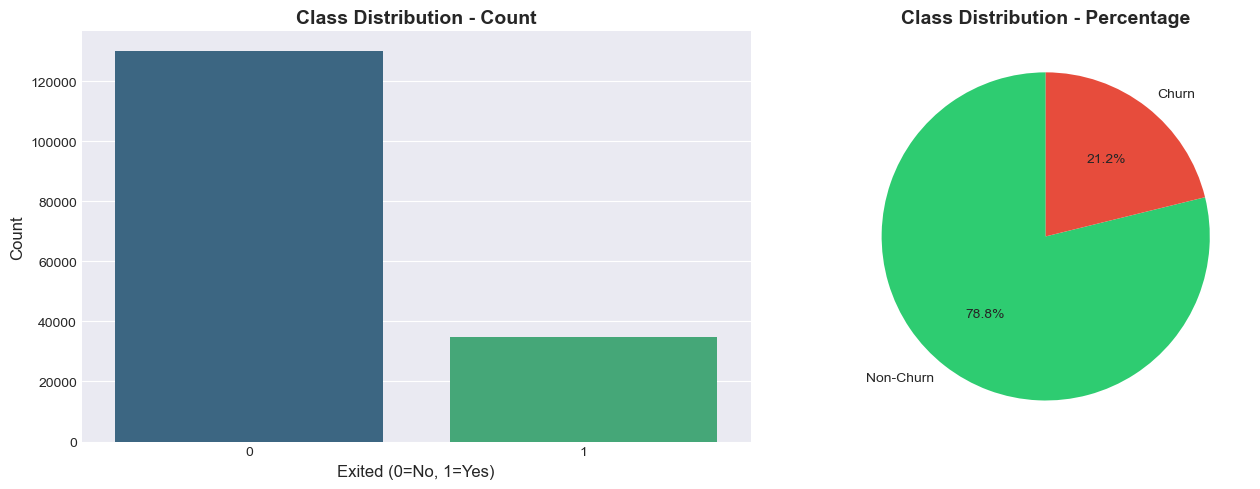

In [20]:
# 2. DATA LOADING & SUMMARY
train_df = pd.read_csv(r"C:\Users\soura\train.csv")
test_df  = pd.read_csv(r"C:\Users\soura\test.csv")

print("\n" + "="*80)
print("DATASET OVERVIEW")
print("="*80)

print("\nFirst 5 rows of the dataset:")
display(train_df.head())   # use display() in notebooks

print(f"\nTraining set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")

print("\nDataset Info:")
train_df.info()

print("\nStatistical Summary:")
display(train_df.describe())

print("\nMissing Values:")
missing_values = train_df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found!")

# Class distribution
print("\n" + "="*80)
print("CLASS DISTRIBUTION")
print("="*80)
churn_counts = train_df['Exited'].value_counts()
churn_percentages = train_df['Exited'].value_counts(normalize=True) * 100

print(f"\nNon-Churn (0): {churn_counts.get(0,0)} ({churn_percentages.get(0,0):.2f}%)")
print(f"Churn (1): {churn_counts.get(1,0)} ({churn_percentages.get(1,0):.2f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=train_df, x='Exited', palette='viridis', ax=axes[0])
axes[0].set_title('Class Distribution - Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Exited (0=No, 1=Yes)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

axes[1].pie(churn_counts, labels=['Non-Churn', 'Churn'], autopct='%1.1f%%', 
            startangle=90, colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Class Distribution - Percentage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [21]:
# 3. DATA PREPROCESSING
print("\n" + "="*80)
print("DATA PREPROCESSING")
print("="*80)

df = train_df.copy()

# Drop ID
if 'id' in df.columns:
    df = df.drop('id', axis=1)
    print("\n✓ Dropped 'id' column")

# Column types
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Exited' in numerical_cols:
    numerical_cols.remove('Exited')

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

# Handle missing values
if df.isnull().sum().sum() > 0:
    for col in numerical_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].mode()[0], inplace=True)
    print("\n✓ Missing values handled")
else:
    print("\n✓ No missing values to handle")

# Encode categoricals
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"✓ Encoded '{col}': {len(le.classes_)} unique values")

# Features / target
X = df.drop('Exited', axis=1)
y = df['Exited']
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
print(f"\n✓ Data split completed: Training {X_train.shape[0]}, Test {X_test.shape[0]}")

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrame (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print("\n✓ Feature scaling completed using StandardScaler")



DATA PREPROCESSING

✓ Dropped 'id' column

Categorical columns: ['Surname', 'Geography', 'Gender']
Numerical columns: ['CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

✓ No missing values to handle
✓ Encoded 'Surname': 2797 unique values
✓ Encoded 'Geography': 3 unique values
✓ Encoded 'Gender': 2 unique values

Features shape: (165034, 12)
Target shape: (165034,)

✓ Data split completed: Training 132027, Test 33007

✓ Feature scaling completed using StandardScaler


In [24]:
# 4. MODEL TRAINING

print("\n" + "="*80)
print("MODEL TRAINING")
print("="*80)

models = {}
results = []
# Logistic Regression (Baseline)
print("\n[1/4] Training Logistic Regression (Baseline)...")
lr_model = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
models['Logistic Regression'] = lr_model
print("✓ Logistic Regression trained")

# Random Forest
print("\n[2/4] Training Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
models['Random Forest'] = rf_model
print("✓ Random Forest trained")

# XGBoost default
print("\n[3/4] Training XGBoost Classifier...")
xgb_model = xgb.XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)
models['XGBoost (Default)'] = xgb_model
print("✓ XGBoost (default) trained")

# XGBoost tuning
print("  Tuning XGBoost hyperparameters...")
xgb_params = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}
xgb_grid = GridSearchCV(
    xgb.XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss'),
    xgb_params, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0
)
xgb_grid.fit(X_train_scaled, y_train)
models['XGBoost (Tuned)'] = xgb_grid.best_estimator_
print(f"✓ XGBoost tuned - Best params: {xgb_grid.best_params_}")

# XGBoost default
print("\n[3/4] Training XGBoost Classifier...")
xgb_model = xgb.XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)
models['XGBoost (Default)'] = xgb_model
print("✓ XGBoost (default) trained")

# XGBoost tuning
print("  Tuning XGBoost hyperparameters...")
xgb_params = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}
xgb_grid = GridSearchCV(
    xgb.XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss'),
    xgb_params, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0
)
xgb_grid.fit(X_train_scaled, y_train)
models['XGBoost (Tuned)'] = xgb_grid.best_estimator_
print(f"✓ XGBoost tuned - Best params: {xgb_grid.best_params_}")

# LightGBM default
print("\n[4/4] Training LightGBM Classifier...")
lgb_model = lgb.LGBMClassifier(random_state=RANDOM_SEED, verbose=-1)
lgb_model.fit(X_train_scaled, y_train)
models['LightGBM (Default)'] = lgb_model
print("✓ LightGBM (default) trained")

# LightGBM tuning
print("  Tuning LightGBM hyperparameters...")
lgb_params = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'num_leaves': [31, 50]
}
lgb_grid = GridSearchCV(
    lgb.LGBMClassifier(random_state=RANDOM_SEED, verbose=-1),
    lgb_params, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0
)
lgb_grid.fit(X_train_scaled, y_train)
models['LightGBM (Tuned)'] = lgb_grid.best_estimator_
print(f"✓ LightGBM tuned - Best params: {lgb_grid.best_params_}")



MODEL TRAINING

[1/4] Training Logistic Regression (Baseline)...
✓ Logistic Regression trained

[2/4] Training Random Forest Classifier...
✓ Random Forest trained

[3/4] Training XGBoost Classifier...
✓ XGBoost (default) trained
  Tuning XGBoost hyperparameters...
✓ XGBoost tuned - Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

[3/4] Training XGBoost Classifier...
✓ XGBoost (default) trained
  Tuning XGBoost hyperparameters...
✓ XGBoost tuned - Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

[4/4] Training LightGBM Classifier...
✓ LightGBM (default) trained
  Tuning LightGBM hyperparameters...
✓ LightGBM tuned - Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'num_leaves': 50}


In [25]:
# 5. MODEL EVALUATION
print("\n" + "="*80)
print("MODEL EVALUATION")
print("="*80)

for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print("\n" + "="*80)
print("MODEL COMPARISON TABLE")
print("="*80)
display(results_df)

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\n🏆 Best Model: {best_model_name} (ROC-AUC: {results_df.iloc[0]['ROC-AUC']:.4f})")



MODEL EVALUATION

Evaluating Logistic Regression...
  Accuracy:  0.8248
  Precision: 0.6677
  Recall:    0.3424
  F1-Score:  0.4526
  ROC-AUC:   0.8050

Evaluating Random Forest...
  Accuracy:  0.8614
  Precision: 0.7433
  Recall:    0.5271
  F1-Score:  0.6168
  ROC-AUC:   0.8804

Evaluating XGBoost (Default)...
  Accuracy:  0.8655
  Precision: 0.7422
  Recall:    0.5584
  F1-Score:  0.6373
  ROC-AUC:   0.8888

Evaluating XGBoost (Tuned)...
  Accuracy:  0.8664
  Precision: 0.7455
  Recall:    0.5599
  F1-Score:  0.6395
  ROC-AUC:   0.8919

Evaluating LightGBM (Default)...
  Accuracy:  0.8664
  Precision: 0.7487
  Recall:    0.5546
  F1-Score:  0.6372
  ROC-AUC:   0.8912

Evaluating LightGBM (Tuned)...
  Accuracy:  0.8665
  Precision: 0.7468
  Recall:    0.5583
  F1-Score:  0.6389
  ROC-AUC:   0.8917

MODEL COMPARISON TABLE


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,XGBoost (Tuned),0.866422,0.745472,0.559851,0.639464,0.891876
5,LightGBM (Tuned),0.866483,0.746792,0.558276,0.638918,0.891716
4,LightGBM (Default),0.866362,0.748695,0.554553,0.637164,0.891227
2,XGBoost (Default),0.865513,0.742150,0.558419,0.637307,0.888786
1,Random Forest,0.861423,0.743336,0.527062,0.616790,0.880406
0,Logistic Regression,0.824795,0.667691,0.342354,0.452627,0.804970



🏆 Best Model: XGBoost (Tuned) (ROC-AUC: 0.8919)


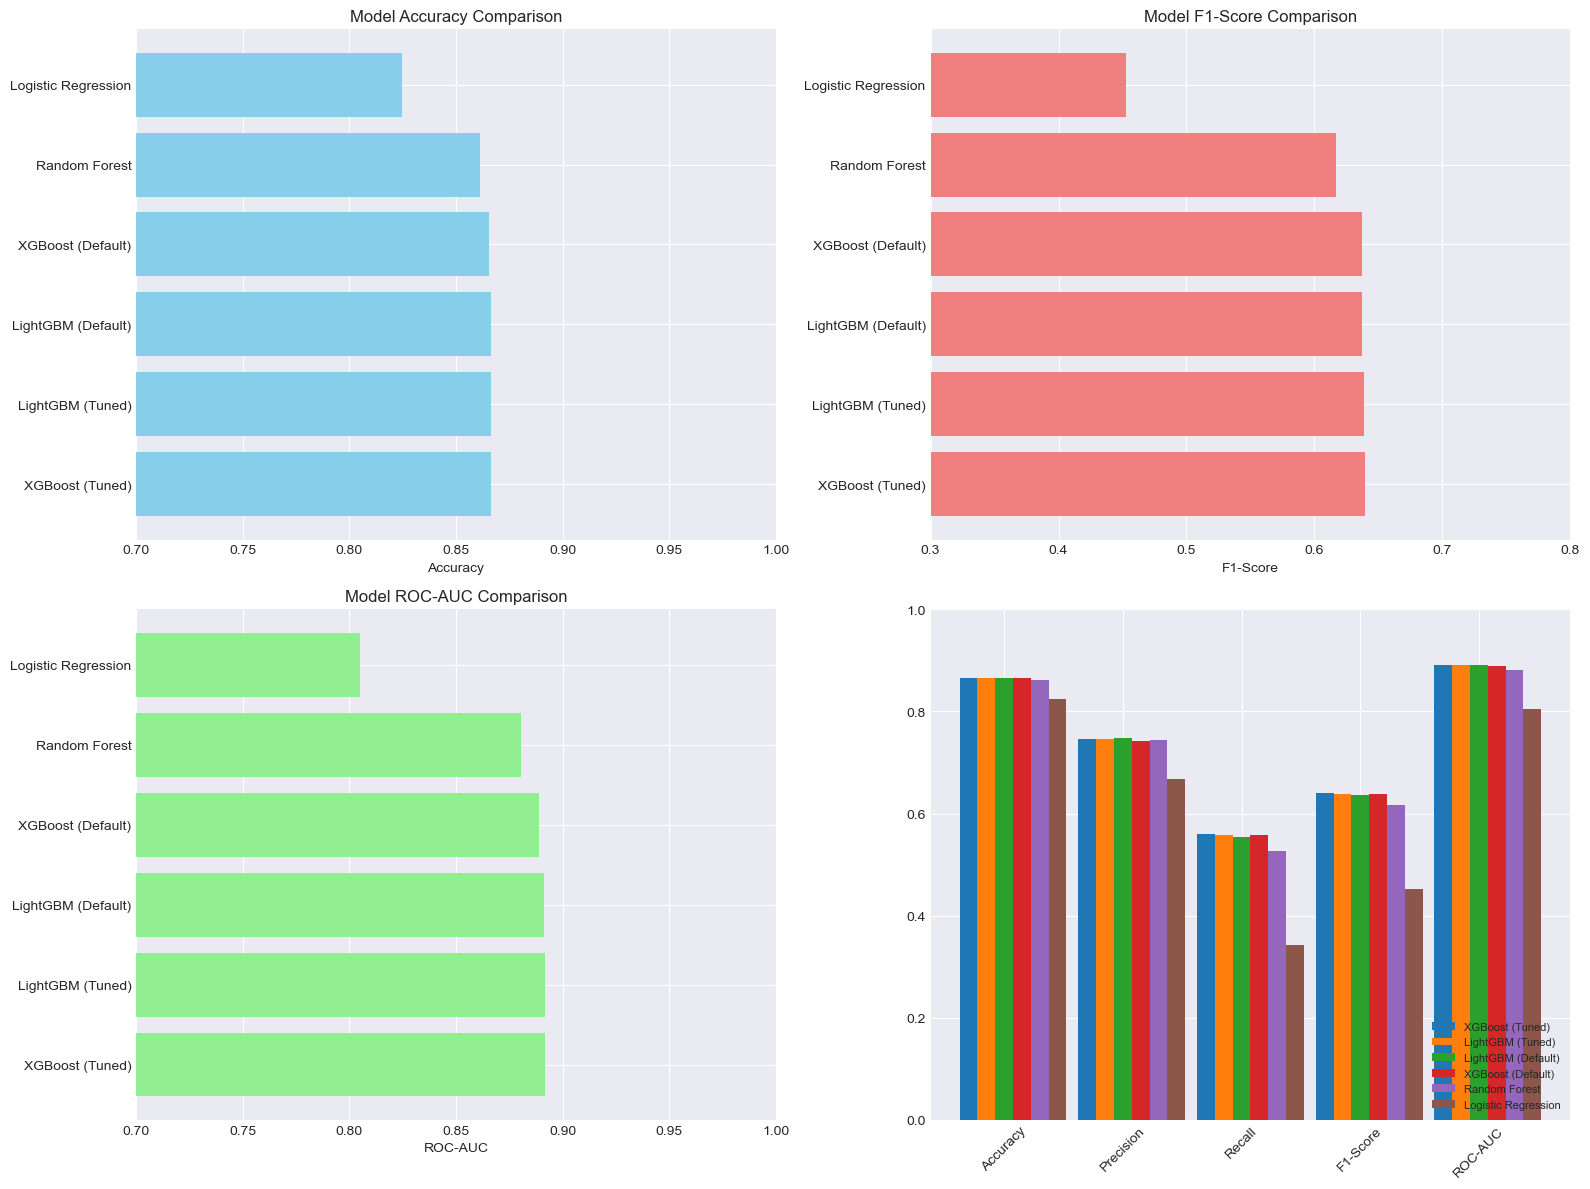

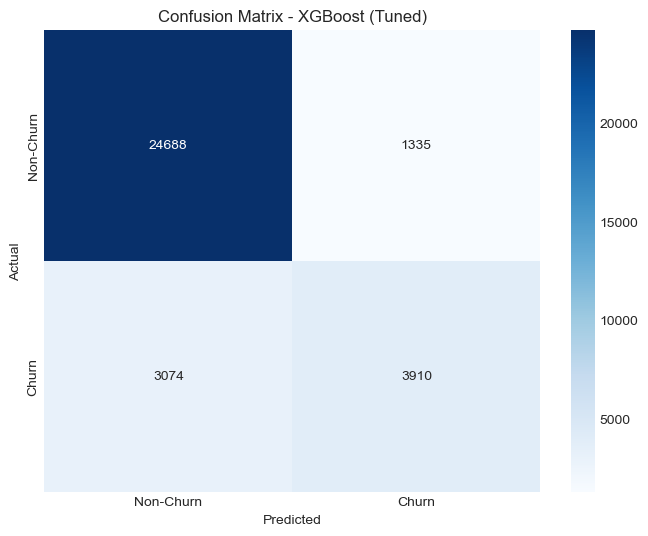


Classification Report:
              precision    recall  f1-score   support

   Non-Churn       0.89      0.95      0.92     26023
       Churn       0.75      0.56      0.64      6984

    accuracy                           0.87     33007
   macro avg       0.82      0.75      0.78     33007
weighted avg       0.86      0.87      0.86     33007



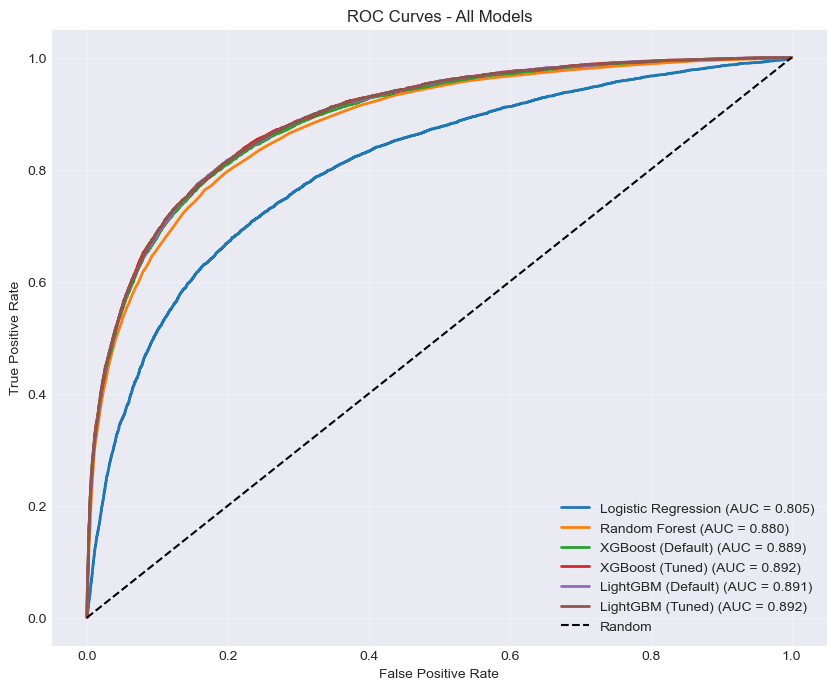

In [26]:
# Visual comparisons
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].barh(results_df['Model'], results_df['Accuracy'], color='skyblue')
axes[0, 0].set_xlabel('Accuracy'); axes[0, 0].set_title('Model Accuracy Comparison'); axes[0,0].set_xlim([0.7,1.0])

axes[0, 1].barh(results_df['Model'], results_df['F1-Score'], color='lightcoral')
axes[0, 1].set_xlabel('F1-Score'); axes[0, 1].set_title('Model F1-Score Comparison'); axes[0,1].set_xlim([0.3,0.8])

axes[1, 0].barh(results_df['Model'], results_df['ROC-AUC'], color='lightgreen')
axes[1, 0].set_xlabel('ROC-AUC'); axes[1, 0].set_title('Model ROC-AUC Comparison'); axes[1,0].set_xlim([0.7,1.0])

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot)); width = 0.15
for idx, (_, row) in enumerate(results_df.iterrows()):
    values = [row[metric] for metric in metrics_to_plot]
    axes[1, 1].bar(x + idx * width, values, width, label=row['Model'])
axes[1,1].set_xticks(x + width * 2); axes[1,1].set_xticklabels(metrics_to_plot, rotation=45)
axes[1,1].legend(loc='lower right', fontsize=8); axes[1,1].set_ylim([0,1])
plt.tight_layout(); plt.show()

# Confusion matrix & classification report for best model
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Non-Churn', 'Churn'],
            yticklabels=['Non-Churn', 'Churn'])
plt.title(f'Confusion Matrix - {best_model_name}'); plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Non-Churn', 'Churn']))

# ROC curves
plt.figure(figsize=(10,8))
for model_name, model in models.items():
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})', linewidth=2)
plt.plot([0,1],[0,1],'k--', label='Random'); plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models'); plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.show()



FEATURE IMPORTANCE ANALYSIS


,Feature,Importance
8,NumOfProducts,0.388467
5,Age,0.191743
10,IsActiveMember,0.185619
4,Gender,0.069153
3,Geography,0.068842
7,Balance,0.034074
9,HasCrCard,0.012679
1,Surname,0.012091
11,EstimatedSalary,0.009932
2,CreditScore,0.009778


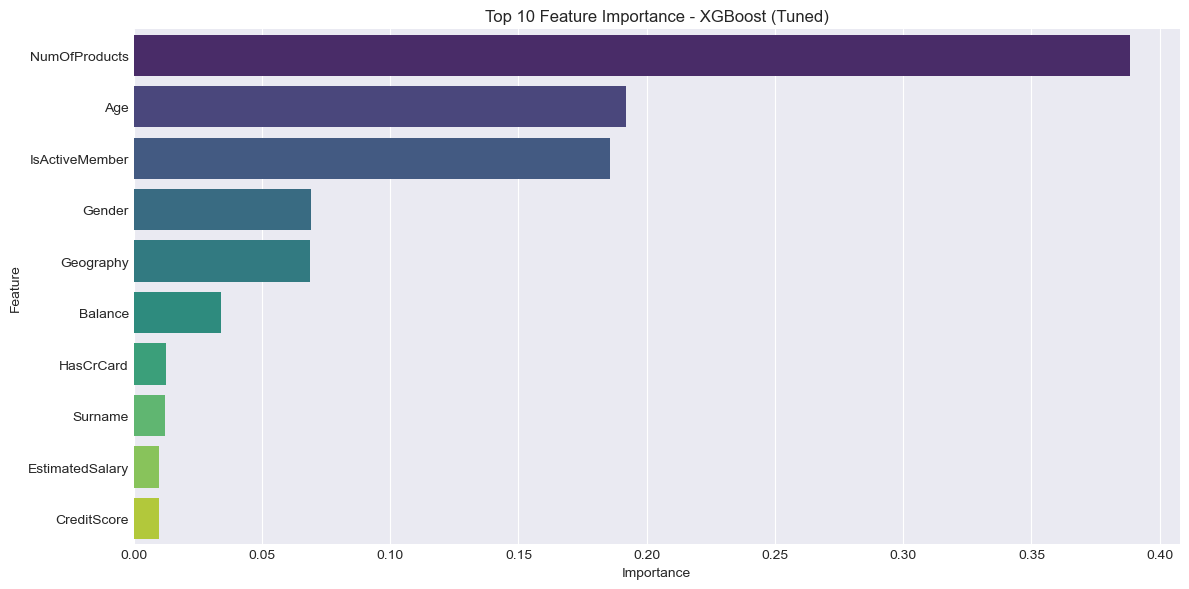


Top features interpretation:
  • NumOfProducts: 0.3885
  • Age: 0.1917
  • IsActiveMember: 0.1856
  • Gender: 0.0692
  • Geography: 0.0688


In [27]:
# 6. FEATURE IMPORTANCE
print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    display(feature_importance.head(10))

    plt.figure(figsize=(12,6))
    top_features = feature_importance.head(10)
    sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis')
    plt.title(f'Top 10 Feature Importance - {best_model_name}'); plt.tight_layout(); plt.show()

    print("\nTop features interpretation:")
    for idx, row in feature_importance.head(5).iterrows():
        print(f"  • {row['Feature']}: {row['Importance']:.4f}")

elif hasattr(best_model, 'coef_'):
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': np.abs(best_model.coef_[0])
    }).sort_values('Importance', ascending=False)
    display(feature_importance.head(10))
    plt.figure(figsize=(12,6))
    top_features = feature_importance.head(10)
    sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis')
    plt.title(f'Top 10 Feature Importance - {best_model_name}'); plt.tight_layout(); plt.show()


In [28]:
# 7. SAVE RESULTS
print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

model_filename = 'best_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_model, file)
print(f"✓ Best model saved as '{model_filename}'")

scaler_filename = 'scaler.pkl'
with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)
print(f"✓ Scaler saved as '{scaler_filename}'")

encoders_filename = 'label_encoders.pkl'
with open(encoders_filename, 'wb') as file:
    pickle.dump(label_encoders, file)
print(f"✓ Label encoders saved as '{encoders_filename}'")

# Predictions
y_pred_final = best_model.predict(X_test_scaled)
y_pred_proba_final = best_model.predict_proba(X_test_scaled)[:, 1]
predictions_df = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred_final, 'Probability': y_pred_proba_final})
predictions_filename = 'predictions.csv'
predictions_df.to_csv(predictions_filename, index=False)
print(f"✓ Predictions saved as '{predictions_filename}'")

results_filename = 'model_comparison.csv'
results_df.to_csv(results_filename, index=False)
print(f"✓ Model comparison saved as '{results_filename}'")



SAVING RESULTS
✓ Best model saved as 'best_model.pkl'
✓ Scaler saved as 'scaler.pkl'
✓ Label encoders saved as 'label_encoders.pkl'
✓ Predictions saved as 'predictions.csv'
✓ Model comparison saved as 'model_comparison.csv'
